In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix


In [2]:
df = pd.read_csv("diabetes_dataset.csv")

In [3]:
#Make race one column
race_cols = [
    "race:AfricanAmerican",
    "race:Asian",
    "race:Other",
    "race:Hispanic",
    "race:Caucasian"
]

df["race"] = df[race_cols].idxmax(axis=1).str.replace("race:", "")

In [4]:
#drop location
df = df.drop(columns=['location'])
df = df.drop(columns=['race:AfricanAmerican', "race:Asian", "race:Other", "race:Hispanic", "race:Caucasian"])

In [5]:
#remove other in gender
df = df[df["gender"].isin(["Male", "Female"])]



In [6]:
df.head()

,year,gender,age,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes,race
0,2020,Female,32.0,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif...",Other
1,2015,Female,29.0,0,0,never,19.95,5.0,90,0,Healthy BMI range.,Asian
2,2015,Male,18.0,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ...",Other
3,2015,Male,41.0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif...",Caucasian
4,2016,Female,52.0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ...",AfricanAmerican


In [7]:
import os
import matplotlib.pyplot as plt

# Create a local folder inside your project
output_dir = "LR"
os.makedirs(output_dir, exist_ok=True)


In [8]:

TARGET_COL = "diabetes"           
SENSITIVE_COLS = ["gender", "race"]
#keep sensitive attribute aside for evaluation
sensitive = df[SENSITIVE_COLS].copy()
#Features
X = df.drop(columns=[TARGET_COL] + SENSITIVE_COLS)
y = df[TARGET_COL]

In [9]:
#train/test split
X_train, X_test, y_train, y_test, sens_train, sens_test = train_test_split(
    X, y, sensitive, test_size=0.3, random_state=42, stratify=y
)


In [10]:
gender_test = sens_test["gender"].reset_index(drop=True)
race_test   = sens_test["race"].reset_index(drop=True)


In [11]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ]
)

log_reg = LogisticRegression(max_iter=1000)

log_reg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", log_reg),
    ]
)

log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)


/Users/isabellebustamante/miniconda3/envs/ai_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [12]:
def confusion_rates(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    eps = 1e-8  # avoid division by zero

    metrics = {}
    metrics["TPR"] = (tp + fp) / (tp + fp + tn + fn + eps)  # predicted positive rate
    metrics["FPR"] = fp / (fp + tn + eps)                  # false positive rate
    metrics["FNR"] = fn / (fn + tp + eps)                  # false negative rate
    metrics["ACC"] = (tp + tn) / (tp + tn + fp + fn + eps) # accuracy (group-specific)
    return metrics


In [13]:
def group_fairness_table(y_true, y_pred, group_values, group_name, model_name):
    rows = []
    for g in sorted(group_values.unique()):
        mask = (group_values == g)
        rates = confusion_rates(y_true[mask], y_pred[mask])
        row = {
            "Group": group_name,
            "Subgroup": g,
            "Model": model_name,
        }
        row.update(rates)
        rows.append(row)
    return rows

rows = []
rows += group_fairness_table(y_test.reset_index(drop=True),
                             pd.Series(y_pred_lr),
                             gender_test,
                             "Gender",
                             "LogReg")


# You can do the same for race_test
fairness_df = pd.DataFrame(rows)
fairness_df


,Group,Subgroup,Model,TPR,FPR,FNR,ACC
0,Gender,Female,LogReg,0.053070,0.006712,0.369148,0.966368
1,Gender,Male,LogReg,0.068503,0.006158,0.371291,0.957276


In [14]:
def group_fairness_table(y_true, y_pred, group_values, group_name, model_name):
    rows = []
    for g in sorted(group_values.unique()):
        mask = (group_values == g)
        rates = confusion_rates(y_true[mask], y_pred[mask])
        row = {
            "Group": group_name,
            "Subgroup": g,
            "Model": model_name,
        }
        row.update(rates)
        rows.append(row)
    return rows

rows = []
rows += group_fairness_table(y_test.reset_index(drop=True),
                             pd.Series(y_pred_lr),
                             race_test,
                             "Race",
                             "LogReg")


# You can do the same for race_test
fairness_df1 = pd.DataFrame(rows)
fairness_df1


,Group,Subgroup,Model,TPR,FPR,FNR,ACC
0,Race,AfricanAmerican,LogReg,0.061999,0.005578,0.372973,0.961067
1,Race,Asian,LogReg,0.055963,0.004732,0.390963,0.962525
2,Race,Caucasian,LogReg,0.059571,0.006679,0.376923,0.961551
3,Race,Hispanic,LogReg,0.060846,0.006996,0.355289,0.963593
4,Race,Other,LogReg,0.058963,0.008487,0.352688,0.964316


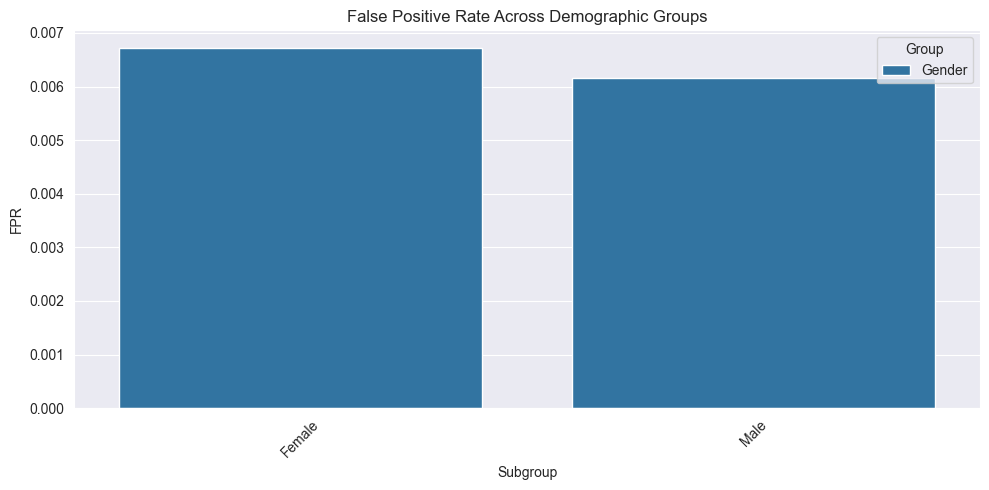

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming fairness_df contains: Group, Subgroup, Model, FPR, ...
df_fpr = fairness_df.copy()

plt.figure(figsize=(10,5))
sns.barplot(data=df_fpr, x="Subgroup", y="FPR", hue="Group")
plt.title("False Positive Rate Across Demographic Groups")
plt.ylabel("FPR")
plt.xticks(rotation=45)
plt.tight_layout()
# Save your figure
plt.savefig(f"{output_dir}/FPR_Gender.png")
plt.show()



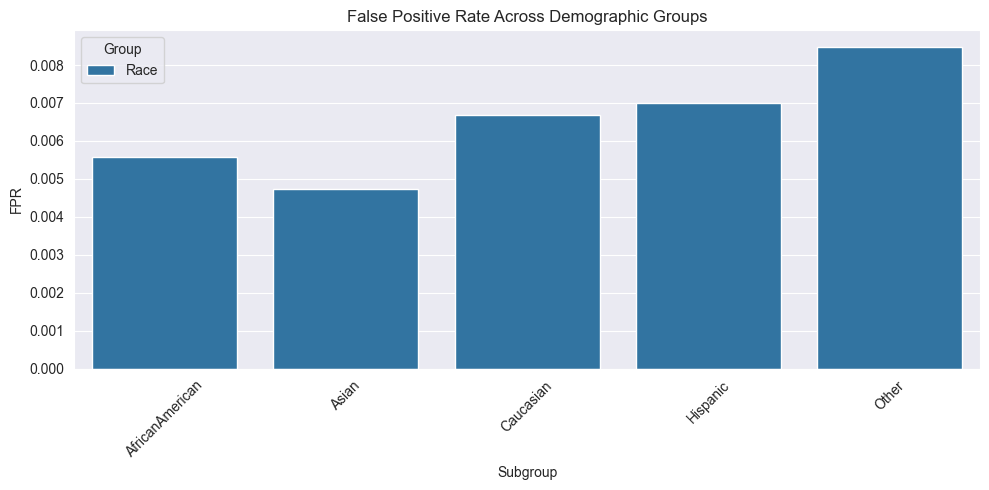

In [16]:


# Assuming fairness_df contains: Group, Subgroup, Model, FPR, ...
df_fpr1 = fairness_df1.copy()

plt.figure(figsize=(10,5))
sns.barplot(data=df_fpr1, x="Subgroup", y="FPR", hue="Group")
plt.title("False Positive Rate Across Demographic Groups")
plt.ylabel("FPR")
plt.xticks(rotation=45)
plt.tight_layout()
# Save your figure
plt.savefig(f"{output_dir}/FPR_Race.png")
plt.show()


In [17]:
###Compute GENDER equalized opportunity
# Filter gender rows
gender_df = fairness_df[fairness_df["Group"]=="Gender"].copy()

# Identify reference group (highest TPR)
ref_group_gender = gender_df.loc[gender_df["TPR"].idxmax(), "Subgroup"]
print("Reference group (Gender):", ref_group_gender)

# Compute Equalized Opportunity
def compute_equalized_opportunity(df, reference_group):
    ref_tpr = df.loc[df["Subgroup"] == reference_group, "TPR"].values[0]
    df["EOpp_gap"] = (df["TPR"] - ref_tpr).abs()
    return df

gender_equalized = compute_equalized_opportunity(gender_df.copy(), ref_group_gender)
gender_equalized


Reference group (Gender): Male


,Group,Subgroup,Model,TPR,FPR,FNR,ACC,EOpp_gap
0,Gender,Female,LogReg,0.053070,0.006712,0.369148,0.966368,0.015433
1,Gender,Male,LogReg,0.068503,0.006158,0.371291,0.957276,0.000000


In [18]:
###Compute RACE equalized opportunity
# Filter gender rows
race_df = fairness_df1[fairness_df1["Group"]=="Race"].copy()

# Identify reference group (highest TPR)
ref_group_race = race_df.loc[race_df["TPR"].idxmax(), "Subgroup"]
print("Reference group (Race):", ref_group_race)

# Compute Equalized Opportunity
def compute_equalized_opportunity(df, reference_group):
    ref_tpr = df.loc[df["Subgroup"] == reference_group, "TPR"].values[0]
    df["EOpp_gap"] = (df["TPR"] - ref_tpr).abs()
    return df

race_equalized = compute_equalized_opportunity(race_df.copy(), ref_group_race)
race_equalized

Reference group (Race): AfricanAmerican


,Group,Subgroup,Model,TPR,FPR,FNR,ACC,EOpp_gap
0,Race,AfricanAmerican,LogReg,0.061999,0.005578,0.372973,0.961067,0.000000
1,Race,Asian,LogReg,0.055963,0.004732,0.390963,0.962525,0.006036
2,Race,Caucasian,LogReg,0.059571,0.006679,0.376923,0.961551,0.002428
3,Race,Hispanic,LogReg,0.060846,0.006996,0.355289,0.963593,0.001153
4,Race,Other,LogReg,0.058963,0.008487,0.352688,0.964316,0.003036


In [19]:
###Equalized odds
def equalized_odds(df, reference_group):
    ref_row = df.loc[df["Subgroup"] == reference_group]
    ref_tpr = ref_row["TPR"].values[0]
    ref_fpr = ref_row["FPR"].values[0]
    
    df["EOdds_gap"] = 0.5 * (
        (df["TPR"] - ref_tpr).abs() +
        (df["FPR"] - ref_fpr).abs()
    )
    return df



In [20]:
# 1) Filter to gender rows
gender_df = fairness_df[fairness_df["Group"] == "Gender"].copy()

# reference = subgroup with highest TPR
ref_gender = gender_df.loc[gender_df["TPR"].idxmax(), "Subgroup"]

gender_eq = compute_equalized_opportunity(gender_df.copy(), ref_gender)
gender_eq = equalized_odds(gender_eq, ref_gender)

gender_eq




,Group,Subgroup,Model,TPR,FPR,FNR,ACC,EOpp_gap,EOdds_gap
0,Gender,Female,LogReg,0.053070,0.006712,0.369148,0.966368,0.015433,0.007994
1,Gender,Male,LogReg,0.068503,0.006158,0.371291,0.957276,0.000000,0.000000


In [21]:
# Filter race groups
race_df = fairness_df1[fairness_df1["Group"] == "Race"].copy()

# Reference group = highest TPR
ref_race = race_df.loc[race_df["TPR"].idxmax(), "Subgroup"]
print("Reference race group:", ref_race)

# Equalized Opportunity (TPR only)
def equalized_opportunity(df, reference_group):
    ref_tpr = df.loc[df["Subgroup"] == reference_group, "TPR"].values[0]
    df["EOpp_gap"] = (df["TPR"] - ref_tpr).abs()
    return df

# Equalized Odds (TPR + FPR)
def equalized_odds(df, reference_group):
    ref_row = df.loc[df["Subgroup"] == reference_group]
    ref_tpr = ref_row["TPR"].values[0]
    ref_fpr = ref_row["FPR"].values[0]
    
    df["EOdds_gap"] = 0.5 * (
        (df["TPR"] - ref_tpr).abs() +
        (df["FPR"] - ref_fpr).abs()
    )
    return df

# Compute fairness metrics
race_eq = equalized_opportunity(race_df.copy(), ref_race)
race_eq = equalized_odds(race_eq, ref_race)

race_eq


Reference race group: AfricanAmerican


,Group,Subgroup,Model,TPR,FPR,FNR,ACC,EOpp_gap,EOdds_gap
0,Race,AfricanAmerican,LogReg,0.061999,0.005578,0.372973,0.961067,0.000000,0.000000
1,Race,Asian,LogReg,0.055963,0.004732,0.390963,0.962525,0.006036,0.003441
2,Race,Caucasian,LogReg,0.059571,0.006679,0.376923,0.961551,0.002428,0.001765
3,Race,Hispanic,LogReg,0.060846,0.006996,0.355289,0.963593,0.001153,0.001285
4,Race,Other,LogReg,0.058963,0.008487,0.352688,0.964316,0.003036,0.002973
